# Function And Weight Checks

This notebook turns Luis's whiteboard idea into two concrete diagnostics for the deterministic relation setup.

The data generator gives us a known clean target:

```text
Y_clean = f(X)
Y = Y_clean + epsilon
```

The contrastive encoder does not directly output `fhat(x)`, so we estimate it with a small post-hoc ridge probe: freeze `encoder_x`, fit a linear probe from the learned X embedding to `Y_clean`, then sweep one raw coordinate and plot the recovered curve.

The second check looks at the learned linear score kernel `W_x.T @ W_y`. For a coordinatewise relation, diagonal structure means the model is mostly matching `x_j` to `y_j` instead of mixing coordinates.


## 1. Imports And Paths

The path setup lets this notebook work when Jupyter starts either in the repository root or inside `experiment-notebooks/`.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

GLOBAL_SEED = 123
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "contrastive_encoders").exists():
        module_root = candidate
        break
else:
    raise RuntimeError("Could not find the contrastive_encoders package folder.")

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

PLOT_DIR = module_root / "research-outputs" / "report-plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)
print("module_root:", module_root)
print("plot output:", PLOT_DIR)


DEVICE: cpu
module_root: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders
plot output: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/research-outputs/report-plots


In [2]:
import importlib

import contrastive_encoders
from contrastive_encoders import data, interpretability, plotting, training

for module in [data, interpretability, training, plotting]:
    importlib.reload(module)

importlib.reload(contrastive_encoders)

from contrastive_encoders import (
    TrainConfig,
    deterministic_relation,
    fit_ridge_probe,
    friendly_results_table,
    generate_deterministic_relation_dataset,
    predict_ridge_probe,
    set_report_plot_style,
    train_one_model_with_artifacts,
)

set_report_plot_style()


## 2. Probe Helpers

`fhat` below means: frozen `encoder_x`, followed by a ridge probe trained to recover the clean deterministic target. This is not a new training loss; it is an interpretability diagnostic for the representation we already learned.


In [3]:
def standardize_like_training(X: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_scale = X_train.std(axis=0, ddof=1, keepdims=True)
    x_scale = np.where(x_scale > 1e-12, x_scale, 1.0)
    return (X - x_mean) / x_scale


@torch.no_grad()
def encode_x_numpy(model: torch.nn.Module, X_standardized: np.ndarray, device: str) -> np.ndarray:
    model.eval()
    X_tensor = torch.tensor(X_standardized, dtype=torch.float32, device=device)
    return model.encoder_x(X_tensor).detach().cpu().numpy()


def true_f_values(x_values: np.ndarray, relationship: str) -> np.ndarray:
    x_column = np.asarray(x_values, dtype=float).reshape(-1, 1)
    return deterministic_relation(x_column, q=1, relationship=relationship)[:, 0]


def deterministic_coordinate_probe_curve(
    run,
    raw_dataset,
    relationship: str,
    config_name: str,
    coordinate: int = 0,
    sweep_values: np.ndarray | None = None,
    base_observation: int | None = None,
    device: str = DEVICE,
    probe_alpha: float = 1e-3,
) -> pd.DataFrame:
    if raw_dataset.Z_y_train is None:
        raise ValueError("raw_dataset.Z_y_train must contain clean deterministic targets.")
    if coordinate < 0 or coordinate >= raw_dataset.Y_train.shape[1]:
        raise ValueError("coordinate must index a Y coordinate.")
    if base_observation is not None and not (0 <= base_observation < raw_dataset.X_test.shape[0]):
        raise ValueError("base_observation must index a held-out observation.")

    if sweep_values is None:
        lo, hi = np.quantile(raw_dataset.X_train[:, coordinate], [0.01, 0.99])
        sweep = np.linspace(lo, hi, 161)
    else:
        sweep = np.asarray(sweep_values, dtype=float)

    probe = fit_ridge_probe(
        z_train=run.z_x_train,
        target_train=raw_dataset.Z_y_train,
        alpha=probe_alpha,
    )

    if base_observation is None:
        X_sweep = np.zeros((len(sweep), raw_dataset.X_train.shape[1]))
        base_label = "zero baseline"
    else:
        X_sweep = np.repeat(raw_dataset.X_test[[base_observation]], len(sweep), axis=0)
        base_label = f"held-out row {base_observation}"

    X_sweep[:, coordinate] = sweep
    X_sweep_standardized = standardize_like_training(X_sweep, raw_dataset.X_train)
    z_sweep = encode_x_numpy(run.model, X_sweep_standardized, device=device)
    y_pred = predict_ridge_probe(probe, z_sweep)

    return pd.DataFrame(
        {
            "config": config_name,
            "base": base_label,
            "coordinate": coordinate,
            "x_value": sweep,
            "true_y": true_f_values(sweep, relationship),
            "probed_y": y_pred[:, coordinate],
        }
    )


def save_current_figure(fig: plt.Figure, filename: str) -> Path:
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print("saved", path)
    return path


In [4]:
def plot_fhat_curves(
    curves: pd.DataFrame,
    title: str,
    filename: str | None = None,
) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    true_curve = curves[["x_value", "true_y"]].drop_duplicates().sort_values("x_value")
    ax.plot(
        true_curve["x_value"],
        true_curve["true_y"],
        color="#202830",
        linewidth=2.4,
        label="true f(x)",
    )

    for config_name, subset in curves.groupby("config", sort=False):
        subset = subset.sort_values("x_value")
        ax.plot(
            subset["x_value"],
            subset["probed_y"],
            linewidth=2.0,
            label=f"fhat via {config_name}",
        )

    ax.axhline(0, linestyle=":", color="#5C6670", linewidth=1.0)
    ax.axvline(0, linestyle=":", color="#5C6670", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("Swept raw x_j")
    ax.set_ylabel("Clean target y_j")
    ax.grid(axis="both", alpha=0.75)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

    if filename is not None:
        save_current_figure(fig, filename)
    return fig


## 3. Scalar Function Check

This is the cleanest version of the whiteboard plot. With `p=q=1`, there is one input coordinate, one output coordinate, and the curve is literally `y = f(x) + epsilon`.

Change `SCALAR_RELATIONSHIP` to `linear`, `cubic`, `exponential`, `signed_log`, or `sine` to reuse the same diagnostic.


In [5]:
SCALAR_RELATIONSHIP = "cubic"
SCALAR_TARGET_SNR = 20.0
SCALAR_X_STD = 1.5
SCALAR_EPOCHS = 300

scalar_dataset = generate_deterministic_relation_dataset(
    n_train=256,
    n_test=512,
    p=1,
    q=1,
    relationship=SCALAR_RELATIONSHIP,
    target_snr=SCALAR_TARGET_SNR,
    rng=np.random.default_rng(GLOBAL_SEED + 5000),
    x_std=SCALAR_X_STD,
)

scalar_configs = [
    TrainConfig(
        name="Linear encoder",
        architecture="linear",
        hidden_dim=0,
        nonlinear_scale=0.0,
        embedding_dim=4,
        epochs=SCALAR_EPOCHS,
    ),
    TrainConfig(
        name="MLP nonlinear alpha=0.10",
        architecture="residual",
        hidden_dim=16,
        nonlinear_scale=0.10,
        embedding_dim=4,
        epochs=SCALAR_EPOCHS,
    ),
]

scalar_runs = {}
scalar_records = []

for config_index, config in enumerate(scalar_configs):
    run = train_one_model_with_artifacts(
        dataset=scalar_dataset,
        config=config,
        seed=GLOBAL_SEED + 5100 + config_index,
        device=DEVICE,
    )
    scalar_runs[config.name] = run
    scalar_records.append(
        {
            "config": config.name,
            "final_loss": run.metrics["final_loss"],
            "test_pair_separation": run.metrics["test_pair_separation"],
            "test_top5_pair_match_accuracy": run.metrics["test_top5_pair_match_accuracy"],
            "x_probe_r2_z_y": run.metrics["x_probe_r2_z_y"],
            "mean_nonlinear_to_linear_ratio": run.metrics["mean_nonlinear_to_linear_ratio"],
        }
    )

display(friendly_results_table(pd.DataFrame(scalar_records).round(4)))


,Model,final_loss,Test true-pair separation,Test top-5 retrieval accuracy,X probe R^2 for Z_y,Mean nonlinear/linear ratio
0,Linear encoder,10.9575,0.0374,0.0098,0.6676,NaN
1,MLP nonlinear alpha=0.10,10.9606,0.0394,0.0117,0.6298,0.1007


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/research-outputs/report-plots/scalar-cubic-true-f-vs-probed-fhat.png


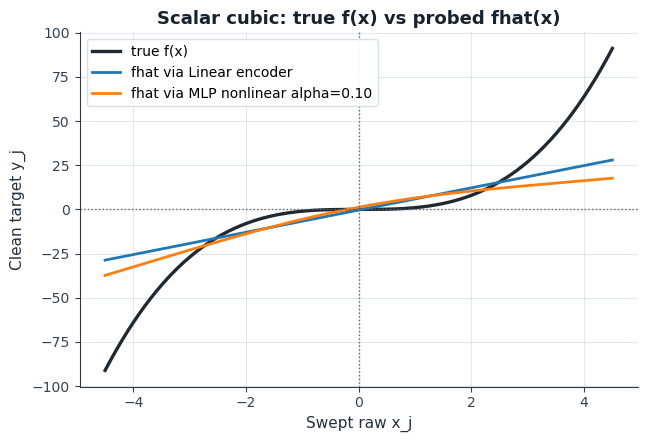

In [6]:
scalar_sweep = np.linspace(-3 * SCALAR_X_STD, 3 * SCALAR_X_STD, 181)

scalar_curves = pd.concat(
    [
        deterministic_coordinate_probe_curve(
            run=run,
            raw_dataset=scalar_dataset,
            relationship=SCALAR_RELATIONSHIP,
            config_name=config_name,
            coordinate=0,
            sweep_values=scalar_sweep,
            base_observation=None,
            device=DEVICE,
        )
        for config_name, run in scalar_runs.items()
    ],
    ignore_index=True,
)

plot_fhat_curves(
    scalar_curves,
    title=f"Scalar {SCALAR_RELATIONSHIP}: true f(x) vs probed fhat(x)",
    filename=f"scalar-{SCALAR_RELATIONSHIP}-true-f-vs-probed-fhat.png",
);


## 4. 128-Dimensional Weight Check

For the linear branches, the raw dot-product score has an interaction kernel:

```text
<W_x x, W_y y> = x.T @ (W_x.T @ W_y) @ y
```

So `W_x.T @ W_y` is a useful first weight check. In a coordinatewise relation, a diagonal-looking heatmap means the model is mostly scoring `x_j` against `y_j`.

Caveat: if `embedding_dim=4`, this matrix has rank at most 4. It cannot become a 128-dimensional identity matrix. That rank bottleneck is part of what this diagnostic makes visible.


In [7]:
def linear_interaction_matrix(model: torch.nn.Module) -> np.ndarray:
    W_x = model.encoder_x.linear_weight().detach().cpu().numpy()
    W_y = model.encoder_y.linear_weight().detach().cpu().numpy()
    return W_x.T @ W_y


def diagonal_alignment_summary(matrix: np.ndarray) -> dict[str, float]:
    m = min(matrix.shape)
    square = matrix[:m, :m]
    diag_abs = np.abs(np.diag(square))
    off_mask = ~np.eye(m, dtype=bool)
    off_abs = np.abs(square[off_mask])
    return {
        "mean_abs_diagonal": float(diag_abs.mean()),
        "mean_abs_off_diagonal": float(off_abs.mean()),
        "diagonal_to_off_diagonal_ratio": float(diag_abs.mean() / max(off_abs.mean(), 1e-12)),
        "max_abs_weight": float(np.abs(matrix).max()),
        "matrix_rank": int(np.linalg.matrix_rank(matrix)),
    }


def plot_linear_interaction_heatmap(
    matrix: np.ndarray,
    title: str,
    filename: str | None = None,
    max_coordinates: int = 128,
) -> plt.Figure:
    shown = matrix[:max_coordinates, :max_coordinates]
    vmax = np.max(np.abs(shown))
    vmax = vmax if vmax > 1e-12 else 1.0

    fig, ax = plt.subplots(figsize=(6.0, 5.2))
    image = ax.imshow(
        shown.T,
        origin="lower",
        aspect="auto",
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.plot(
        [0, shown.shape[0] - 1],
        [0, shown.shape[1] - 1],
        color="#202830",
        linewidth=1.0,
        alpha=0.75,
    )
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="linear score weight")

    if filename is not None:
        save_current_figure(fig, filename)
    return fig


In [8]:
WEIGHT_RELATIONSHIP = "linear"
WEIGHT_TARGET_SNR = 20.0
WEIGHT_X_STD = 1.0
WEIGHT_P = 128
WEIGHT_Q = 128
WEIGHT_EPOCHS = 300

weight_dataset = generate_deterministic_relation_dataset(
    n_train=256,
    n_test=512,
    p=WEIGHT_P,
    q=WEIGHT_Q,
    relationship=WEIGHT_RELATIONSHIP,
    target_snr=WEIGHT_TARGET_SNR,
    rng=np.random.default_rng(GLOBAL_SEED + 6000),
    x_std=WEIGHT_X_STD,
)

weight_configs = [
    TrainConfig(
        name="Linear encoder d=4",
        architecture="linear",
        hidden_dim=0,
        nonlinear_scale=0.0,
        embedding_dim=4,
        epochs=WEIGHT_EPOCHS,
    ),
    TrainConfig(
        name="Linear encoder d=32",
        architecture="linear",
        hidden_dim=0,
        nonlinear_scale=0.0,
        embedding_dim=32,
        epochs=WEIGHT_EPOCHS,
    ),
]

weight_runs = {}
weight_records = []

for config_index, config in enumerate(weight_configs):
    run = train_one_model_with_artifacts(
        dataset=weight_dataset,
        config=config,
        seed=GLOBAL_SEED + 6100 + config_index,
        device=DEVICE,
    )
    matrix = linear_interaction_matrix(run.model)
    weight_runs[config.name] = {"run": run, "matrix": matrix}
    weight_records.append(
        {
            "config": config.name,
            "embedding_dim": config.embedding_dim,
            "test_pair_separation": run.metrics["test_pair_separation"],
            "test_top5_pair_match_accuracy": run.metrics["test_top5_pair_match_accuracy"],
            "x_probe_r2_z_y": run.metrics["x_probe_r2_z_y"],
            **diagonal_alignment_summary(matrix),
        }
    )

display(friendly_results_table(pd.DataFrame(weight_records).round(4)))


,Model,Embedding dim,Test true-pair separation,Test top-5 retrieval accuracy,X probe R^2 for Z_y,mean_abs_diagonal,mean_abs_off_diagonal,diagonal_to_off_diagonal_ratio,max_abs_weight,matrix_rank
0,Linear encoder d=4,4,0.6648,0.1133,0.0140,0.0206,0.0083,2.4941,0.0670,4
1,Linear encoder d=32,32,0.2355,0.8984,0.1122,0.0634,0.0137,4.6264,0.1293,32


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/research-outputs/report-plots/weight-check-linear-linear-encoder-d4.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/research-outputs/report-plots/weight-check-linear-linear-encoder-d32.png


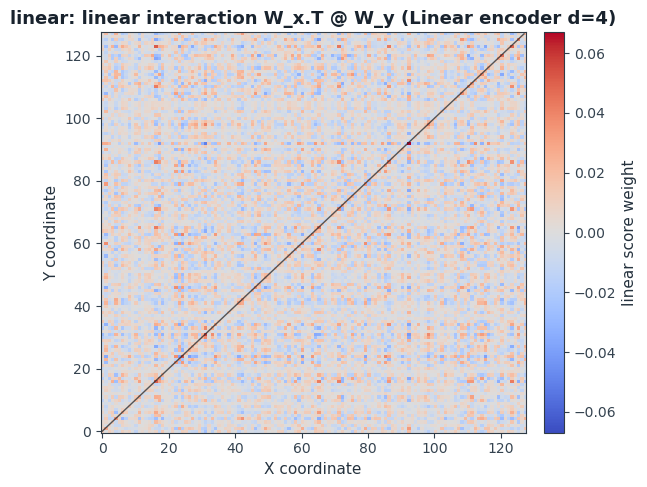

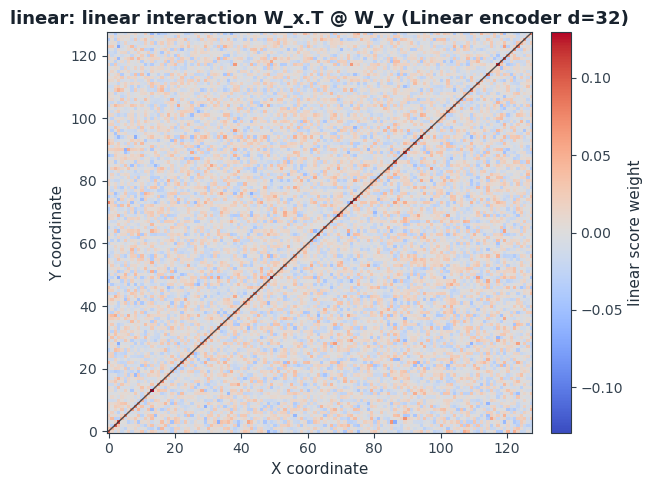

In [9]:
for config_name, artifacts in weight_runs.items():
    safe_name = config_name.lower().replace(" ", "-").replace("=", "")
    plot_linear_interaction_heatmap(
        artifacts["matrix"],
        title=f"{WEIGHT_RELATIONSHIP}: linear interaction W_x.T @ W_y ({config_name})",
        filename=f"weight-check-{WEIGHT_RELATIONSHIP}-{safe_name}.png",
        max_coordinates=128,
    );


## 5. Optional 128-D Function Curve

This repeats the `f` versus `fhat` curve for one coordinate in the 128-dimensional dataset. Because the embedding is low-dimensional, this can expose whether a model is learning a broad paired signal without preserving individual coordinates very well.


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/research-outputs/report-plots/weight-check-128d-linear-coordinate-fhat.png


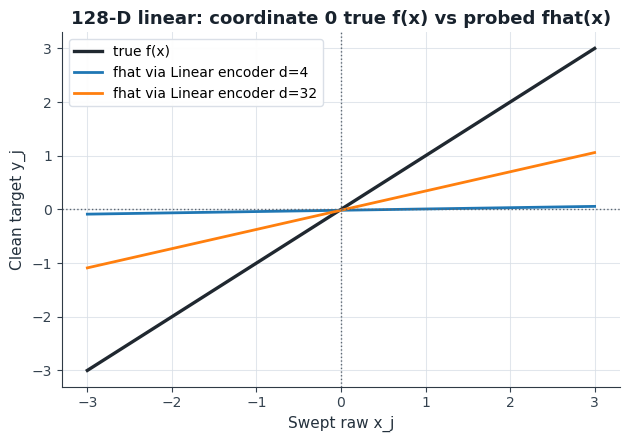

In [10]:
WEIGHT_COORDINATE_TO_SWEEP = 0
weight_sweep = np.linspace(-3 * WEIGHT_X_STD, 3 * WEIGHT_X_STD, 181)

weight_curves = pd.concat(
    [
        deterministic_coordinate_probe_curve(
            run=artifacts["run"],
            raw_dataset=weight_dataset,
            relationship=WEIGHT_RELATIONSHIP,
            config_name=config_name,
            coordinate=WEIGHT_COORDINATE_TO_SWEEP,
            sweep_values=weight_sweep,
            base_observation=None,
            device=DEVICE,
        )
        for config_name, artifacts in weight_runs.items()
    ],
    ignore_index=True,
)

plot_fhat_curves(
    weight_curves,
    title=(
        f"128-D {WEIGHT_RELATIONSHIP}: coordinate "
        f"{WEIGHT_COORDINATE_TO_SWEEP} true f(x) vs probed fhat(x)"
    ),
    filename=f"weight-check-128d-{WEIGHT_RELATIONSHIP}-coordinate-fhat.png",
);


## 6. How To Read These Plots

- If the orange/colored `fhat` curve follows the black true `f` curve, the frozen X encoder contains enough information for a simple probe to recover the deterministic relation.
- If the heatmap has a strong diagonal, the linear score kernel is coordinate-aligned.
- If the low-rank `d=4` heatmap is not diagonal, that is not automatically a bug. A rank-4 score kernel cannot represent 128 independent coordinate matches. Compare it with the `d=32` run to see how much of the limitation is the embedding bottleneck.
- For nonlinear relations, the linear heatmap only inspects the linear branch. The function plot is the better diagnostic for whether the nonlinear representation contains the curve shape.
